#1. Import Library

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import librosa
import librosa.display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import joblib
from collections import Counter

%matplotlib inline

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


#2. Mount Google Drive

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


#3. Load Model

In [4]:
MODEL_DIR = "/content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Output"

# Konstanta yang HARUS sama persis dengan notebook training
SEGMENT_DURATION = 3      # detik
SAMPLE_RATE = 22050
N_MFCC = 20


def load_model(model_dir=MODEL_DIR):

    svm_model = joblib.load(os.path.join(model_dir, "svm_model.pkl"))
    scaler = joblib.load(os.path.join(model_dir, "scaler.pkl"))
    label_encoder = joblib.load(os.path.join(model_dir, "label_encoder.pkl"))
    selected_features_obj = joblib.load(os.path.join(model_dir, "selected_features.pkl"))

    artifacts = {
        "model": svm_model,
        "scaler": scaler,
        "label_encoder": label_encoder,
        "selector": selected_features_obj["selector"],
        "selected_feature_names": selected_features_obj["selected_feature_names"],
    }

    return artifacts


# Memuat model saat notebook dijalankan
model_artifacts = load_model()

print("Model dan seluruh objek preprocessing berhasil dimuat:")
print(f"  - Model SVM        : {type(model_artifacts['model']).__name__}")
print(f"  - Scaler           : {type(model_artifacts['scaler']).__name__}")
print(f"  - Label Encoder    : {list(model_artifacts['label_encoder'].classes_)}")
print(f"  - Jumlah fitur terpilih : {len(model_artifacts['selected_feature_names'])}")

Model dan seluruh objek preprocessing berhasil dimuat:
  - Model SVM        : SVC
  - Scaler           : StandardScaler
  - Label Encoder    : ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
  - Jumlah fitur terpilih : 60


#4. Definisi Seluruh Fungsi

## 4.1 `segment_audio(y, sr)`

In [5]:
def segment_audio(y, sr, segment_duration=SEGMENT_DURATION):

    segment_length = int(segment_duration * sr)
    n_segments = len(y) // segment_length

    segments = [
        y[i * segment_length : (i + 1) * segment_length]
        for i in range(n_segments)
    ]
    return segments


print("Fungsi segment_audio() berhasil didefinisikan.")

Fungsi segment_audio() berhasil didefinisikan.


##4.2 `extract_features(y_segment, sr)`

In [7]:
def extract_features(y_segment, sr, n_mfcc=N_MFCC):

    features = {}

    # 1. MFCC
    mfcc = librosa.feature.mfcc(y=y_segment, sr=sr, n_mfcc=n_mfcc)
    for i in range(n_mfcc):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    # 2. Delta MFCC
    delta_mfcc = librosa.feature.delta(mfcc, order=1)
    for i in range(n_mfcc):
        features[f"delta_mfcc_{i+1}_mean"] = np.mean(delta_mfcc[i])
        features[f"delta_mfcc_{i+1}_std"] = np.std(delta_mfcc[i])

    # 3. Delta-Delta MFCC
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    for i in range(n_mfcc):
        features[f"delta2_mfcc_{i+1}_mean"] = np.mean(delta2_mfcc[i])
        features[f"delta2_mfcc_{i+1}_std"] = np.std(delta2_mfcc[i])

    # 4. Spectral Centroid
    spec_centroid = librosa.feature.spectral_centroid(y=y_segment, sr=sr)
    features["spectral_centroid_mean"] = np.mean(spec_centroid)
    features["spectral_centroid_std"] = np.std(spec_centroid)

    # 5. Spectral Bandwidth
    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y_segment, sr=sr)
    features["spectral_bandwidth_mean"] = np.mean(spec_bandwidth)
    features["spectral_bandwidth_std"] = np.std(spec_bandwidth)

    # 6. Spectral Roll-off
    spec_rolloff = librosa.feature.spectral_rolloff(y=y_segment, sr=sr)
    features["spectral_rolloff_mean"] = np.mean(spec_rolloff)
    features["spectral_rolloff_std"] = np.std(spec_rolloff)

    # 7. Spectral Contrast
    spec_contrast = librosa.feature.spectral_contrast(y=y_segment, sr=sr)
    for i in range(spec_contrast.shape[0]):
        features[f"spectral_contrast_{i+1}_mean"] = np.mean(spec_contrast[i])
        features[f"spectral_contrast_{i+1}_std"] = np.std(spec_contrast[i])

    # 8. Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y=y_segment)
    features["zcr_mean"] = np.mean(zcr)
    features["zcr_std"] = np.std(zcr)

    # 9. Chroma STFT
    chroma = librosa.feature.chroma_stft(y=y_segment, sr=sr)
    for i in range(chroma.shape[0]):
        features[f"chroma_{i+1}_mean"] = np.mean(chroma[i])
        features[f"chroma_{i+1}_std"] = np.std(chroma[i])

    # 10. RMS Energy
    rms = librosa.feature.rms(y=y_segment)
    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    # 11. Tempo
    try:
        tempo_frames = librosa.feature.tempo(y=y_segment, sr=sr, aggregate=None)
        features["tempo_mean"] = np.mean(tempo_frames)
        features["tempo_std"] = np.std(tempo_frames)
    except Exception:
        tempo_value = librosa.feature.tempo(y=y_segment, sr=sr, aggregate=np.mean)
        features["tempo_mean"] = float(np.atleast_1d(tempo_value)[0])
        features["tempo_std"] = 0.0

    return features


print("Fungsi extract_features() berhasil didefinisikan.")

Fungsi extract_features() berhasil didefinisikan.


##4.3 `preprocess_features(features_df)`

In [9]:
def preprocess_features(features_df, artifacts=model_artifacts):

    selector = artifacts["selector"]
    scaler = artifacts["scaler"]

    # Feature Selection (transform saja, TIDAK fit)
    features_selected = selector.transform(features_df)

    # Standardisasi (transform saja, TIDAK fit)
    feature_matrix = scaler.transform(features_selected)

    return feature_matrix


print("Fungsi preprocess_features() berhasil didefinisikan.")

Fungsi preprocess_features() berhasil didefinisikan.


##4.4 `predict_segments(feature_matrix)`

In [10]:
def predict_segments(feature_matrix, artifacts=model_artifacts):

    model = artifacts["model"]
    label_encoder = artifacts["label_encoder"]

    label_numeric = model.predict(feature_matrix)
    label_genre = label_encoder.inverse_transform(label_numeric)

    return label_numeric, label_genre


print("Fungsi predict_segments() berhasil didefinisikan.")

Fungsi predict_segments() berhasil didefinisikan.


##4.5 `majority_voting(segment_predictions)`

In [11]:
def majority_voting(segment_predictions):

    vote_counts = Counter(segment_predictions)
    total_segments = len(segment_predictions)

    final_genre = vote_counts.most_common(1)[0][0]

    vote_percent = {
        genre: (count / total_segments) * 100
        for genre, count in vote_counts.items()
    }

    return {
        "final_genre": final_genre,
        "vote_counts": dict(vote_counts),
        "vote_percent": vote_percent,
    }


print("Fungsi majority_voting() berhasil didefinisikan.")

Fungsi majority_voting() berhasil didefinisikan.


##4.6 `predict_audio(file_path)`

In [12]:
def predict_audio(file_path, artifacts=model_artifacts, show_plots=True):

    filename = os.path.basename(file_path)

    # ----- 1. Load Audio -----
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    duration = librosa.get_duration(y=y, sr=sr)

    # ----- 2. Visualisasi Waveform & Mel Spectrogram -----
    if show_plots:
        plt.figure(figsize=(12, 4))
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Waveform - {filename}")
        plt.xlabel("Waktu (detik)")
        plt.ylabel("Amplitudo")
        plt.tight_layout()
        plt.show()

        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        plt.figure(figsize=(12, 4))
        librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel")
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Mel-Spectrogram - {filename}")
        plt.tight_layout()
        plt.show()

    # ----- 3. Segmentasi -----
    segments = segment_audio(y, sr)
    n_segments = len(segments)

    # ----- 4. Feature Extraction (per segmen) -----
    segment_feature_rows = [extract_features(seg, sr) for seg in segments]
    features_df = pd.DataFrame(segment_feature_rows)

    # Menjaga urutan kolom identik dengan urutan pembuatan fitur (safety check)
    features_df = features_df[list(segment_feature_rows[0].keys())]

    # ----- 5. Feature Selection + StandardScaler -----
    feature_matrix = preprocess_features(features_df, artifacts)

    # ----- 6. Prediksi Tiap Segmen -----
    label_numeric, label_genre = predict_segments(feature_matrix, artifacts)

    # ----- 7. Majority Voting -----
    voting_result = majority_voting(label_genre)

    # ----- 8. Menampilkan Hasil -----
    print("=" * 45)
    print("Music Genre Classification")
    print("=" * 45)
    print(f"Nama File       : {filename}")
    print(f"Durasi Audio    : {duration:.2f} detik")
    print(f"Jumlah Segmen   : {n_segments}")

    print("\nPrediksi Setiap Segmen:")
    for i, genre in enumerate(label_genre):
        print(f"  Segmen {i+1:2d} : {genre}")

    print("\nJumlah Vote Tiap Genre:")
    for genre, count in sorted(voting_result["vote_counts"].items(), key=lambda x: -x[1]):
        percent = voting_result["vote_percent"][genre]
        print(f"  {genre:10s} : {count} vote ({percent:.1f}%)")

    print("\n" + "=" * 45)
    print(f"Genre Akhir (Majority Voting) : {voting_result['final_genre'].upper()}")
    print("=" * 45)

    # Visualisasi ringkas hasil voting
    if show_plots:
        plt.figure(figsize=(8, 5))
        genres_sorted = sorted(voting_result["vote_counts"].items(), key=lambda x: -x[1])
        genre_names = [g for g, _ in genres_sorted]
        genre_votes = [c for _, c in genres_sorted]

        colors = ["seagreen" if g == voting_result["final_genre"] else "lightgray" for g in genre_names]

        plt.bar(genre_names, genre_votes, color=colors)
        plt.title(f"Hasil Majority Voting - {filename}")
        plt.xlabel("Genre")
        plt.ylabel("Jumlah Vote")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # Mengembalikan hasil secara terstruktur (untuk kebutuhan integrasi UI)
    return {
        "filename": filename,
        "duration": duration,
        "n_segments": n_segments,
        "segment_predictions": list(label_genre),
        "vote_counts": voting_result["vote_counts"],
        "vote_percent": voting_result["vote_percent"],
        "final_genre": voting_result["final_genre"],
    }


print("Fungsi predict_audio() berhasil didefinisikan.")
print("\nSeluruh fungsi pipeline inference sudah siap digunakan.")

Fungsi predict_audio() berhasil didefinisikan.

Seluruh fungsi pipeline inference sudah siap digunakan.


#5. Memilih File Audio

In [13]:
file_path = "/content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Testing/metal.mp3"

print(f"File audio yang akan diuji (dari Drive): {file_path}")

File audio yang akan diuji (dari Drive): /content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Testing/metal.mp3


#6. Menjalankan `predict_audio(file_path)`

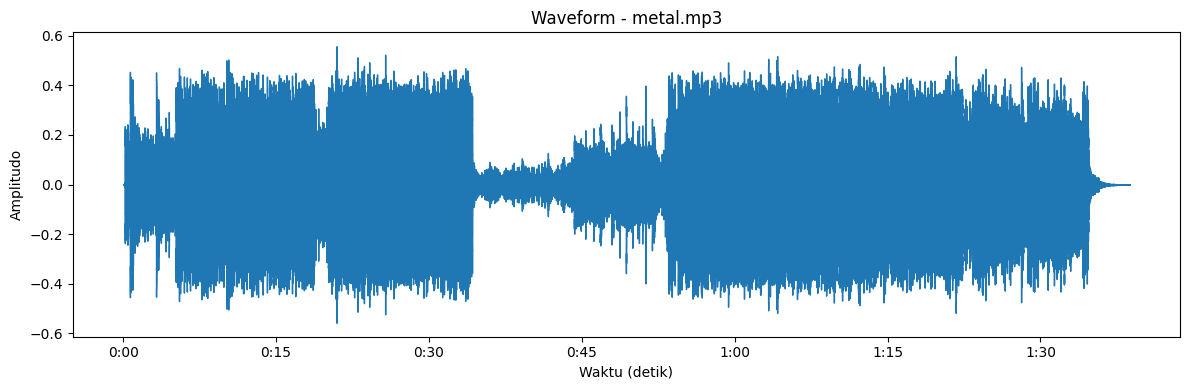

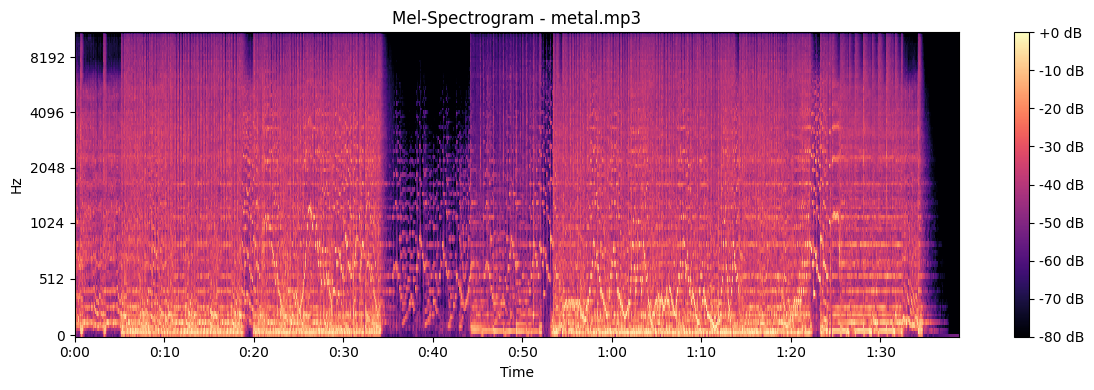

Music Genre Classification
Nama File       : metal.mp3
Durasi Audio    : 98.76 detik
Jumlah Segmen   : 32

Prediksi Setiap Segmen:
  Segmen  1 : metal
  Segmen  2 : metal
  Segmen  3 : metal
  Segmen  4 : metal
  Segmen  5 : metal
  Segmen  6 : metal
  Segmen  7 : metal
  Segmen  8 : metal
  Segmen  9 : metal
  Segmen 10 : country
  Segmen 11 : metal
  Segmen 12 : classical
  Segmen 13 : classical
  Segmen 14 : jazz
  Segmen 15 : classical
  Segmen 16 : jazz
  Segmen 17 : jazz
  Segmen 18 : jazz
  Segmen 19 : metal
  Segmen 20 : country
  Segmen 21 : country
  Segmen 22 : metal
  Segmen 23 : country
  Segmen 24 : metal
  Segmen 25 : metal
  Segmen 26 : metal
  Segmen 27 : metal
  Segmen 28 : country
  Segmen 29 : metal
  Segmen 30 : metal
  Segmen 31 : metal
  Segmen 32 : classical

Jumlah Vote Tiap Genre:
  metal      : 19 vote (59.4%)
  country    : 5 vote (15.6%)
  classical  : 4 vote (12.5%)
  jazz       : 4 vote (12.5%)

Genre Akhir (Majority Voting) : METAL


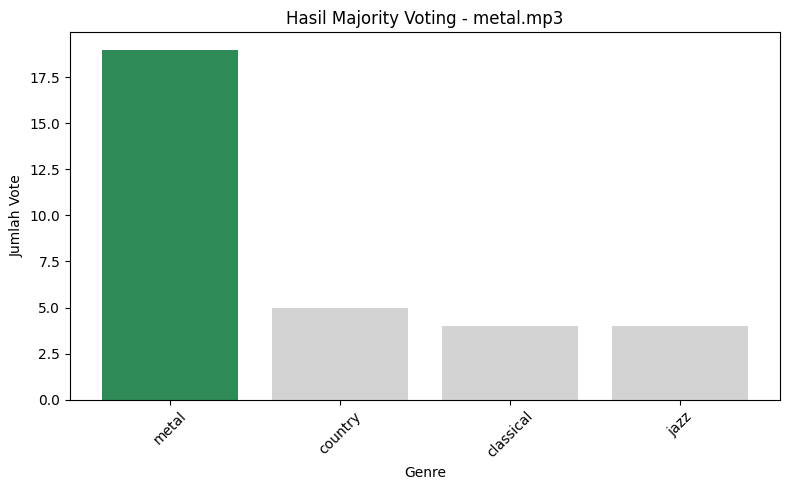


Hasil dalam bentuk dictionary (untuk kebutuhan integrasi UI):
{'filename': 'metal.mp3', 'duration': 98.76, 'n_segments': 32, 'segment_predictions': ['metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'metal', 'country', 'metal', 'classical', 'classical', 'jazz', 'classical', 'jazz', 'jazz', 'jazz', 'metal', 'country', 'country', 'metal', 'country', 'metal', 'metal', 'metal', 'metal', 'country', 'metal', 'metal', 'metal', 'classical'], 'vote_counts': {'metal': 19, 'country': 5, 'classical': 4, 'jazz': 4}, 'vote_percent': {'metal': 59.375, 'country': 15.625, 'classical': 12.5, 'jazz': 12.5}, 'final_genre': 'metal'}


In [14]:
result = predict_audio(file_path)

# Contoh mengakses hasil secara terstruktur (berguna untuk integrasi UI)
print("\nHasil dalam bentuk dictionary (untuk kebutuhan integrasi UI):")
print(result)